In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import torch
from tqdm import tqdm
from torch.nn.functional import pad

In [135]:
from transformers import GPT2LMHeadModel, GPT2TokenizerFast
from transformers import LlamaForCausalLM, LlamaTokenizerFast

import argparse
import pickle
import os
import json
import pandas as pd

model_id = "unsloth/Meta-Llama-3.1-8B-bnb-4bit"
#model_id="gpt2-large"
device = "cuda:1"
perplexity_func = "p1"

if "gpt2" in model_id:
    #model = GPT2LMHeadModel.from_pretrained(model_id).to(device)
    tokenizer = GPT2TokenizerFast.from_pretrained(model_id)
    start_of_sentence=" "
if "Llama" in model_id:
    #model = LlamaForCausalLM.from_pretrained(model_id, device_map="auto")
    tokenizer = LlamaTokenizerFast.from_pretrained(model_id)
    start_of_sentence='<|begin_of_text|>'

The tokenizer class you load from this checkpoint is not the same type as the class this function is called from. It may result in unexpected tokenization. 
The tokenizer class you load from this checkpoint is 'PreTrainedTokenizer'. 
The class this function is called from is 'LlamaTokenizerFast'.


### Plotting

In [136]:
import os
os.chdir("/u/sebono/conversational_dominance/information_exchange_labelling/")
os.getcwd()

'/u/sebono/conversational_dominance/information_exchange_labelling'

In [137]:
from utils import correlation_heatmap, compute_dominance_per_spk, rolling_kde_heatmap_with_turns, remove_match_prefix_ppl, compute_graph_perplexity, display_turns_colored_by_kde

In [138]:
import pandas as pd
import re
import numpy as np

candor_df = pd.read_csv("/u/sebono/conversational_dominance/data/processed/CANDOR/conversations.csv")
candor_df.head()

,file_name,file_content
0,7595d874-c1cb-4aef-918f-3c81f3a84324,<SPK0> this is Yeah. Mhm. Mhm. Yeah. Yeah. Mot...
1,66768810-879d-4e2f-b5f5-ecc67d298104,<SPK0> Uh huh uh huh. Yeah. <SPK1> Yeah. All r...
2,dc3d0ae4-8d20-4d1d-8e0c-82c85a79b26e,<SPK1> Yeah. Right. Mhm. Mhm. Mhm. Okay. Yeah....
3,fb50ccf7-1a5a-4d80-b4f0-d5d1a1fd1135,<SPK0> Hi there and move away. <SPK1> mm. <SPK...
4,73c201ef-8c32-43d4-b642-dcedf4aa5c7f,<SPK0> Yeah. Okay. Yeah. Mhm. Yeah. Mhm Uh huh...


In [139]:
with open("/u/sebono/conversational_dominance/data/external/CANDOR/map.pkl", "rb") as file:
    maps_loaded = pickle.load(file)

In [140]:
file_name = "fb50ccf7-1a5a-4d80-b4f0-d5d1a1fd1135"
dialog = candor_df[candor_df['file_name']==file_name]["file_content"][3]

In [141]:
import re 
pattern = r'<(?:SPK[0-9]|MOD)>'
dialog_lines = re.sub(r"[\[\(].*?[\]\)]", "", dialog).replace("<", "\n<").split("\n")[1:]
matches = [f"{match}" for match in re.findall(pattern, f"{start_of_sentence}".join(dialog_lines))]
token_list = [tokenizer(token, return_tensors="pt").input_ids[0] for token in dialog_lines]
encodings = tokenizer(f"{start_of_sentence}".join(dialog_lines), return_tensors="pt")
assert np.cumsum([len(token) for token in token_list])[-1] == encodings.input_ids[0].shape
assert len(matches) == len(dialog_lines)

In [142]:
all_data = pd.DataFrame({})
model_name = "llama"
for p_name in ['p1','p2','p3']:
    file_name_sample = f'/u/sebono/conversational_dominance/notebooks/information_exchange_labelling/dataset_perplexity_results/CANDOR_{p_name}_unsloth/Meta-Llama-3.1-8B-bnb-4bit/dominance_scores_{file_name}.pkl'
    with open(file_name_sample, 'rb') as f:
        all_data[f"{p_name}"] = pickle.load(f)[file_name]

In [143]:
all_data.keys()

Index(['p1', 'p2', 'p3'], dtype='object')

In [144]:
baselined_ppls_p1_spk = compute_dominance_per_spk(all_data["p1"], token_list, matches, tokenizer)
baselined_ppls_p2_spk = compute_dominance_per_spk(all_data["p2"], token_list, matches, tokenizer)
baselined_ppls_p3_spk = compute_dominance_per_spk(all_data["p3"], token_list, matches, tokenizer)

In [145]:
# Run statistical tests
from scipy import stats
def compute_significance(original_ppls_p_spk, start_of_sentence):
    spk1_clean = np.array(original_ppls_p_spk[f"<SPK0>"])
    spk2_clean = np.array(original_ppls_p_spk[f"<SPK1>"])

    ppl_spk1 = spk1_clean[~np.isnan(spk1_clean)]
    ppl_spk2 = spk2_clean[~np.isnan(spk2_clean)]

    ks_stat, ks_pvalue = stats.ks_2samp(ppl_spk1, ppl_spk2)
    mw_stat, mw_pvalue = stats.mannwhitneyu(ppl_spk1, ppl_spk2, alternative='two-sided')
    tt_stat, tt_pvalue = stats.ttest_ind(ppl_spk1, ppl_spk2, equal_var=False)

    return {
        "Kolmogorov-Smirnov": {"statistic": ks_stat, "p_value": ks_pvalue},
        "Mann-Whitney U": {"statistic": mw_stat, "p_value": mw_pvalue},
        "T-test": {"statistic": tt_stat, "p_value": tt_pvalue}
    }

In [146]:
compute_significance(baselined_ppls_p2_spk, start_of_sentence) , compute_significance(baselined_ppls_p3_spk, start_of_sentence) 

({'Kolmogorov-Smirnov': {'statistic': 0.183441628012394,
   'p_value': 2.035773990753216e-99},
  'Mann-Whitney U': {'statistic': 18221115.0,
   'p_value': 1.4784494081627218e-95},
  'T-test': {'statistic': -9.556387151130405,
   'p_value': 1.445357558527162e-21}},
 {'Kolmogorov-Smirnov': {'statistic': 0.15338525499934158,
   'p_value': 1.5706236262300064e-69},
  'Mann-Whitney U': {'statistic': 27279240.5,
   'p_value': 1.5913334940860307e-79},
  'T-test': {'statistic': 18.848152645604088,
   'p_value': 3.2157121278214624e-78}})

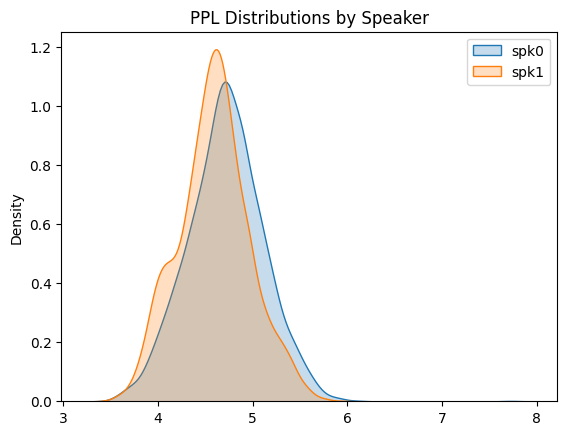

In [147]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.kdeplot(baselined_ppls_p3_spk[f"<SPK0>"], label="spk0", fill=True)
sns.kdeplot(baselined_ppls_p3_spk[f"<SPK1>"], label="spk1", fill=True)
plt.title("PPL Distributions by Speaker")
plt.legend()
plt.show()

In [148]:
# BEFORE
col_1 = ["p1","p2","p3"]
baselined_p2_scores = all_data["p2"]
baselined_p3_scores = all_data["p3"]
baselined_p1_scores = all_data["p1"]
corr, fig_corr, p, fig_p, fig_r = correlation_heatmap(col_1,col_1,all_data)

In [149]:
fig_corr

In [150]:
all_data.bfill(inplace=True)

In [151]:
from transformers import AutoTokenizer
import numpy as np

def remove_match_prefix_ppl(token_list, ppl, matches, tokenizer, min_len=1):
    """
    Removes matching prefixes from each line and filters out entire turns if remaining token length is below threshold.

    Args:
        token_list (List[List[int]]): Tokenized dialog lines.
        ppl (List[float]): Flat list of token-level PPL values.
        matches (List[str]): List of string prefixes to remove from each line.
        tokenizer: HuggingFace tokenizer used.
        min_len (int): Minimum length (after prefix removal) to keep the turn.

    Returns:
        Tuple[
            List[List[int]],  # filtered_tokens
            List[float],      # filtered_ppl
            List[int],        # flat_token_ids
            List[str]         # filtered_matches
        ]
    """
    assert len(token_list) == len(matches), "Mismatch between token list and matches"

    line_offsets = np.cumsum([0] + [len(t) for t in token_list[:-1]])  # start index in flat PPL array

    filtered_tokens = []
    filtered_ppl = []
    flat_token_ids = []
    filtered_matches = []

    for i, (token, match) in enumerate(zip(token_list, matches)):
        tok_match = tokenizer(match, return_tensors="pt")
        match_tok_len = len(tok_match.input_ids[0])

        # Slice off the match prefix
        token_filtered = token[match_tok_len:]

        if len(token_filtered) < min_len:
            continue  # skip turn entirely if below threshold

        # Keep this turn
        filtered_tokens.append(token_filtered)
        filtered_matches.append(match)

        # Extract aligned PPL values
        start = line_offsets[i] + match_tok_len
        end = line_offsets[i] + len(token)
        turn_ppl = ppl[start:end]

        assert len(turn_ppl) == len(token_filtered), f"PPL/token mismatch at turn {i}"
        
        filtered_ppl.extend(turn_ppl)
        flat_token_ids.extend(token_filtered)

    return filtered_tokens, filtered_ppl, flat_token_ids, filtered_matches

In [152]:
all_data.bfill(inplace=True)

In [153]:
filtered_tokens_p1, filtered_ppl_p1, filtered_encodings_p1, filtered_matches_p1 = remove_match_prefix_ppl(token_list, all_data['p1'], matches, tokenizer, min_len=0)
assert np.cumsum([len(token) for token in filtered_tokens_p1])[-1], len(filtered_ppl)

In [154]:
filtered_tokens_p2, filtered_ppl_p2, filtered_encodings_p2, filtered_matches_p2 = remove_match_prefix_ppl(token_list, all_data['p2'], matches, tokenizer, min_len=0)
assert np.cumsum([len(token) for token in filtered_tokens_p2])[-1], len(filtered_ppl)

In [155]:
filtered_tokens_p3, filtered_ppl_p3, filtered_encodings_p3, filtered_matches_p3 = remove_match_prefix_ppl(token_list, all_data['p3'], matches, tokenizer, min_len=0)
assert np.cumsum([len(token) for token in filtered_tokens_p3])[-1], len(filtered_ppl)

In [156]:
assert len(filtered_tokens_p3) == len(token_list)

In [157]:
assert len(filtered_tokens_p1) == len(filtered_tokens_p2)
assert len(filtered_tokens_p1) == len(filtered_tokens_p3)

In [158]:
assert filtered_encodings_p1 == filtered_encodings_p2
assert filtered_encodings_p1 == filtered_encodings_p3
filtered_encodings = filtered_encodings_p1

In [159]:
all_data_filtered = pd.DataFrame({"p1":filtered_ppl_p1,"p2":filtered_ppl_p2, "p3":filtered_ppl_p3 })

In [160]:
col_1 = ["p2","p3"]
corr, fig_corr, p, fig_p, fig_r = correlation_heatmap(col_1,col_1,all_data_filtered)

In [161]:
fig_corr

In [162]:
import os
os.chdir("/u/sebono/conversational_dominance/information_exchange_labelling")
os.getcwd()

'/u/sebono/conversational_dominance/information_exchange_labelling'

In [163]:
from utils import rolling_kde_heatmap_with_turns

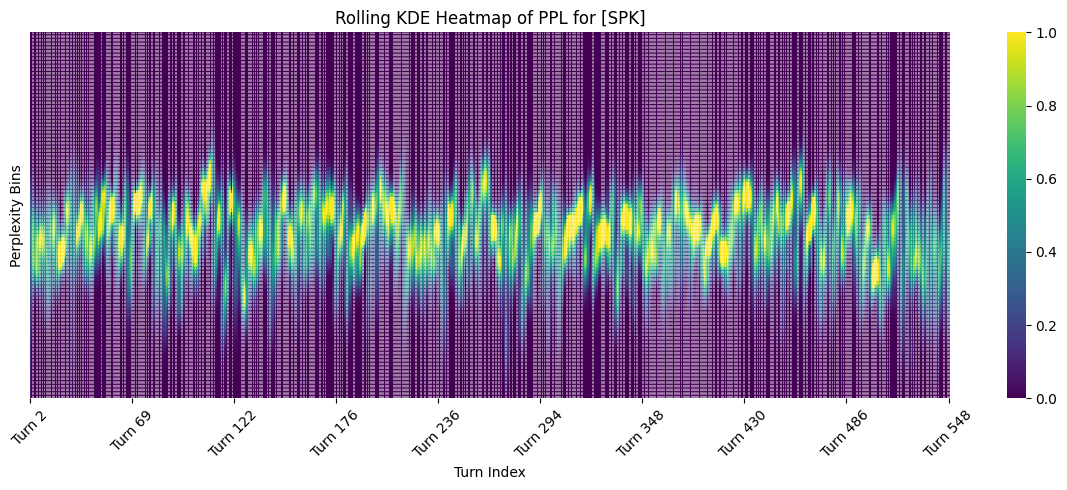

In [164]:
densities_p2 = rolling_kde_heatmap_with_turns(token_list=token_list, ppls=all_data_filtered["p2"],vmin=0, vmax=1.0)

In [165]:
#KMeans (assumes spherical clusters):
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=7, random_state=0)
labels = kmeans.fit_predict(all_data_filtered[["p2","p3"]])


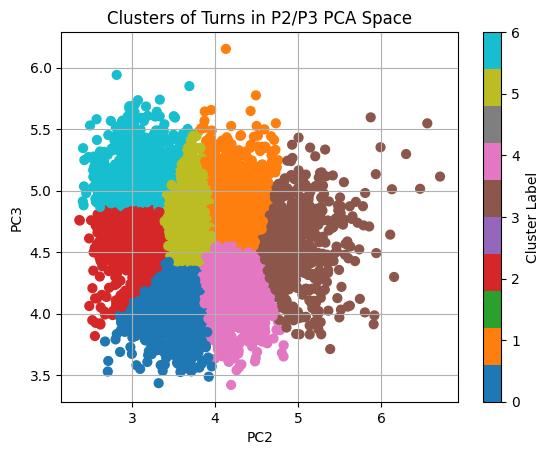

In [166]:
import matplotlib.pyplot as plt
plt.scatter(all_data_filtered["p2"], all_data_filtered["p3"], c=labels, cmap="tab10", s=40)
plt.title("Clusters of Turns in P2/P3 PCA Space")
plt.xlabel("PC2")
plt.ylabel("PC3")
plt.colorbar(label="Cluster Label")
plt.grid(True)
plt.show()


In [167]:
import numpy as np

# Step 1: get turn boundaries from dialog_lines
turn_lengths = [len(t) for t in filtered_tokens_p1]
turn_start = np.cumsum([0] + turn_lengths[:-1])
turn_end = np.cumsum(turn_lengths)

for cluster_id in np.unique(labels):
    print(f"\n--- Cluster {cluster_id} ---")
    cluster_token_indices = set(np.where(labels == cluster_id)[0])

    for start, end in zip(turn_start, turn_end):
        turn_indices = list(range(start, end))
        selected = [i for i in turn_indices if i in cluster_token_indices]
        if selected:
            full_sentence = tokenizer.decode([filtered_encodings[i] for i in turn_indices], skip_special_tokens=True)
            clustered_text = tokenizer.decode([filtered_encodings[i] for i in selected], skip_special_tokens=True)
            print(f"clustered_text: {clustered_text}\nfull_sentence:{full_sentence}")


--- Cluster 0 ---
clustered_text: ?
full_sentence: Who are you? 
clustered_text: 'm. you?
full_sentence: I'm good. How are you? 
clustered_text:  bad. 
full_sentence: aren't too bad. 
clustered_text: . of
full_sentence: Good. I got a couple of dogs running crazy right by 
clustered_text:  
full_sentence: Okay, 
clustered_text: ? 
full_sentence: me. But uh have you done one of these before? 
clustered_text:  
full_sentence: I have. This is actually 
clustered_text:  really? 
full_sentence: Oh, really? 
clustered_text:  my 
full_sentence: So this would be my second 
clustered_text:  
full_sentence: and uh I guess first of all, my name is Cameron, 
clustered_text:  
full_sentence: and 
clustered_text:  in North Dakota. 
full_sentence: I'm in North Dakota. Hey, 
clustered_text:  you. 
full_sentence: David, good to meet you. 
clustered_text:  
full_sentence: Where are 
clustered_text:  you 
full_sentence: you 
clustered_text:  
full_sentence: colorado. 
clustered_text: ado? 
full_sentence:

clustered_text: 's, my folks, they used to always we town
full_sentence: No, it's fine. Right. Uh, my folks, they used to always we always live in the same town. I mean since 
clustered_text:  to married had family stuff. And so year 
full_sentence: forever and then my sister, she moved to Kansas city, got married, had a family and stuff like that. And so this last year they finally moved out there 
clustered_text:  how to deal it guess,
full_sentence: but yeah I just it bums me out because now literally like this is my family and so um yeah it's a bummer, I don't know how to deal with it I guess, you 
clustered_text: ,
full_sentence: Mhm, 
clustered_text: , don't have like a big family and stuff that. We came to the U. S. As, 
full_sentence: you know, we don't have like a big family and stuff like that. We were I came over to the U. S. As a baby, 
clustered_text: .
full_sentence: we were refugees from the kurdish part of Iraq. 
clustered_text:  
full_sentence: Mhm. 
clustered_text:  b

clustered_text:  earth and you, but
full_sentence: to earth and you are, but 
clustered_text:  Yeah,
full_sentence: Yeah, 
clustered_text: 's definitely a better than
full_sentence: there's definitely a lot better than Chelsea's were, so um 
clustered_text: ,
full_sentence: yep. Yeah, 
clustered_text:  she me watch them a
full_sentence: good friend of mine had one and she let me watch them a lot. 
clustered_text: , I love dog
full_sentence: uh yeah, I fell in love with that dog, I mean he was just a sweetheart 
clustered_text: ,
full_sentence: yeah, 
clustered_text: 's one of my trying
full_sentence: that's one of the things my parents are trying to figure out is the dogs will jump on people and 
clustered_text: 's like,
full_sentence: it's like, well, you know, first of all that 
clustered_text:  of course they're going to keep
full_sentence: they kind of realize if it seems to get them petted, then of course they're going to keep doing that behavior. Um 
clustered_text:  yeah
full_se

In [168]:
#DBSCAN (finds dense clusters, doesn't require specifying k):
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=0.3, min_samples=2)
labels = db.fit_predict(all_data_filtered[["p2","p3"]])

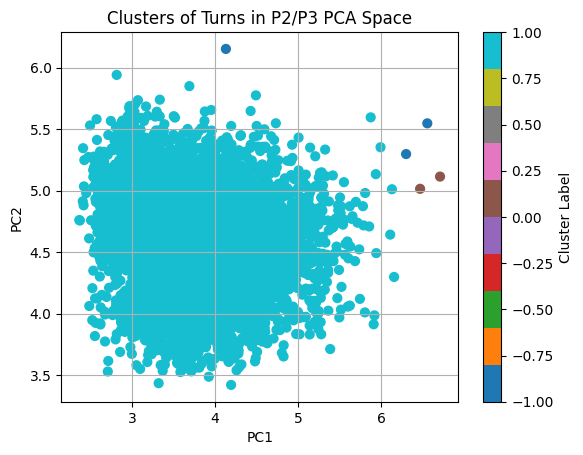

In [169]:
import matplotlib.pyplot as plt
plt.scatter(all_data_filtered["p2"], all_data_filtered["p3"], c=labels, cmap="tab10", s=40)
plt.title("Clusters of Turns in P2/P3 PCA Space")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="Cluster Label")
plt.grid(True)
plt.show()

In [170]:
#Gaussian Mixture Model (softer boundaries):
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=3, random_state=0)
labels = gmm.fit_predict(all_data_filtered[["p2","p3"]])

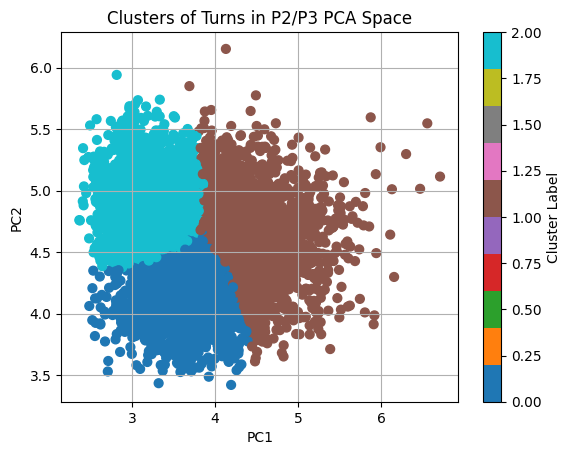

In [171]:
import matplotlib.pyplot as plt
plt.scatter(all_data_filtered["p2"], all_data_filtered["p3"], c=labels, cmap="tab10", s=40)
plt.title("Clusters of Turns in P2/P3 PCA Space")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="Cluster Label")
plt.grid(True)
plt.show()

### Labels

In [172]:
directory = "/u/sebono/conversational_dominance/data/external/CANDOR/transcript_audiophile/"
directory_file = directory + f"{file_name}.csv"
transcript_audiophile = pd.read_csv(directory_file).iloc[1:]
transcript_audiophile.head()

,turn_id,speaker,start,stop,utterance,interval,delta,questions,end_question,overlap,n_words
1,1,5e11882114ae638303c715d9,138.54,138.75,mm.,-0.21,0.21,0,False,True,1
2,2,5d06b3a3ae1dc1000167e533,139.14,139.82,Hold,0.39,0.68,0,False,False,1
3,3,5e11882114ae638303c715d9,139.24,139.86,Who are you?,-0.58,0.62,1,True,True,3
4,4,5d06b3a3ae1dc1000167e533,139.82,140.16,on.,-0.04,0.34,0,False,True,1
5,5,5e11882114ae638303c715d9,140.44,140.76,"Yeah,",0.28,0.32,0,False,False,1


In [173]:
path_annotations = "/u/sebono/conversational_dominance/data/processed/CANDOR/affective_labels/"
annotation_file = path_annotations + f"{file_name}.csv"
affective_labels = pd.read_csv(annotation_file)
affective_labels.iloc[:800]

,timedelta,user_id,f0,intensity,jitter,log_energy,mfcc_0,mfcc_1,mfcc_10,mfcc_11,...,prob_face_anger,prob_face_contempt,prob_face_disgust,prob_face_fear,prob_face_happiness,prob_face_neutral,prob_face_sadness,prob_face_surprise,smile,is_speaking
0,00:00:00,5d06b3a3ae1dc1000167e533,NaN,0.000000,NaN,-99.172266,-511.36688,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
1,00:00:00,5e11882114ae638303c715d9,NaN,0.000000,NaN,-115.977709,-498.45502,NaN,NaN,NaN,...,0.012649,0.014664,0.008122,0.006395,0.732815,0.131040,0.028822,0.065493,1.0,False
2,00:00:01,5d06b3a3ae1dc1000167e533,NaN,0.000000,NaN,-99.172266,-511.36688,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
3,00:00:01,5e11882114ae638303c715d9,NaN,0.000000,NaN,-115.977709,-498.45502,NaN,NaN,NaN,...,0.018427,0.001402,0.000726,0.060252,0.002870,0.564665,0.321175,0.030484,0.0,False
4,00:00:02,5d06b3a3ae1dc1000167e533,NaN,0.000000,NaN,-99.172266,-511.36688,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,00:06:37,5e11882114ae638303c715d9,284.875840,0.967309,2.772961,-16.789192,-149.68724,147.835830,-20.404757,-7.124273,...,0.000827,0.001901,0.001504,0.001714,0.985545,0.001642,0.002015,0.004853,1.0,True
796,00:06:38,5d06b3a3ae1dc1000167e533,131.087234,0.818720,2.998291,-24.506776,-288.93520,168.936400,-0.903103,6.855155,...,0.101271,0.028195,0.170617,0.034829,0.287679,0.144072,0.170187,0.063150,0.0,True
797,00:06:38,5e11882114ae638303c715d9,255.846079,0.848197,2.360290,-46.864940,-437.34300,56.390182,-16.184677,-2.787199,...,0.000166,0.003502,0.000286,0.000315,0.986334,0.000466,0.001313,0.007619,1.0,True
798,00:06:39,5d06b3a3ae1dc1000167e533,148.401107,0.511535,0.741430,-24.567500,-265.55756,161.171500,-10.994461,-8.654724,...,0.035556,0.020511,0.022731,0.042406,0.269517,0.312566,0.118319,0.178394,1.0,True


In [174]:
cols = ["prob_face_anger","prob_face_contempt","prob_face_disgust","prob_face_fear","prob_face_happiness","prob_face_neutral","prob_face_sadness","prob_face_surprise","smile"]

In [175]:
transcript_audiophile["tokens"] = filtered_tokens_p1[1:]

In [176]:
import numpy as np
import pandas as pd
from collections import defaultdict
import torch  # make sure torch is imported

def assign_words_to_bins(df, tokenizer, bin_size=1.0):
    """
    Assigns words to time bins based on uniform spread over the utterance duration.
    Returns: dict of pd.DataFrames, one per speaker
    """
    # Fix nested defaultdict
    bin_tok = defaultdict(lambda: defaultdict(list))
    bin_ppl = defaultdict(lambda: defaultdict(list))
    tok_len = 0

    for _, row in df.iterrows():
        spk = row['speaker']
        start = row["start"]
        stop = row["stop"]
        duration = stop - start
            
        if duration <= 0 or pd.isna(start) or pd.isna(stop):
            continue

        tokens = row["tokens"]
        n_tokens = len(tokens)
        if n_tokens == 0:
            continue

        # Uniformly spread tokens over time
        tok_times = np.linspace(start, stop, n_tokens + 1)
        for i, tok in enumerate(tokens):
            tok_start = tok_times[i]
            tok_end = tok_times[i + 1]

            bin_start_idx = int(np.floor(tok_start / bin_size))
            bin_end_idx = int(np.floor(tok_end / bin_size))

            for b in range(bin_start_idx, bin_end_idx + 1):
                bin_tok[spk][b].append(tok)
                bin_ppl[spk][b].append(tok_len + i)

        tok_len += n_tokens

    # Determine full range of bins
    max_bin = int(np.ceil(df["stop"].max() / bin_size))
    all_bins = list(range(max_bin + 1))
    all_speakers = df["speaker"].unique()

    # Build a DataFrame per speaker
    bins_df = {
        spk: pd.DataFrame([
            {
                "time_bin": b,
                "start_time": b * bin_size,
                "end_time": (b + 1) * bin_size,
                "words": tokenizer.decode(torch.tensor(bin_tok[spk][b]), skip_special_tokens=True) if bin_tok[spk][b] else None,
                "ppl": bin_ppl[spk][b],
                "n_tok": len(bin_tok[spk][b])
            }
            for b in all_bins
        ])
        for spk in all_speakers
    }

    return bins_df


In [177]:
transcript_audiophile

,turn_id,speaker,start,stop,utterance,interval,delta,questions,end_question,overlap,n_words,tokens
1,1,5e11882114ae638303c715d9,138.54,138.75,mm.,-0.21,0.21,0,False,True,1,"[tensor(9653), tensor(13), tensor(220)]"
2,2,5d06b3a3ae1dc1000167e533,139.14,139.82,Hold,0.39,0.68,0,False,False,1,"[tensor(23588), tensor(220)]"
3,3,5e11882114ae638303c715d9,139.24,139.86,Who are you?,-0.58,0.62,1,True,True,3,"[tensor(10699), tensor(527), tensor(499), tens..."
4,4,5d06b3a3ae1dc1000167e533,139.82,140.16,on.,-0.04,0.34,0,False,True,1,"[tensor(389), tensor(13), tensor(220)]"
5,5,5e11882114ae638303c715d9,140.44,140.76,"Yeah,",0.28,0.32,0,False,False,1,"[tensor(22335), tensor(11), tensor(220)]"
...,...,...,...,...,...,...,...,...,...,...,...,...
909,909,5e11882114ae638303c715d9,1795.84,1796.05,"What,",-0.67,0.21,0,False,True,1,"[tensor(3639), tensor(11), tensor(220)]"
910,910,5d06b3a3ae1dc1000167e533,1796.51,1797.26,"back to your game,",0.46,0.75,0,False,False,4,"[tensor(1203), tensor(311), tensor(701), tenso..."
911,911,5e11882114ae638303c715d9,1797.14,1797.95,"yep,",-0.12,0.81,0,False,True,1,"[tensor(379), tensor(752), tensor(11), tensor(..."
912,912,5d06b3a3ae1dc1000167e533,1797.84,1799.85,Get back to your game.,-0.11,2.01,0,False,True,5,"[tensor(2175), tensor(1203), tensor(311), tens..."


In [178]:
speakers = np.unique(transcript_audiophile["speaker"])

In [179]:
cols = ["time_bin", "prob_face_anger","prob_face_contempt","prob_face_disgust","prob_face_fear","prob_face_happiness","prob_face_neutral","prob_face_sadness","prob_face_surprise","smile"]

In [180]:
affective_labels["timedelta"] = pd.to_timedelta(affective_labels["timedelta"])
affective_labels["time_bin"] = affective_labels["timedelta"].dt.total_seconds().astype(int)

In [181]:
affective_labels_spk0 = affective_labels[affective_labels['user_id']==speakers[0]][cols].reset_index(drop=True)
affective_labels_spk1 = affective_labels[affective_labels['user_id']==speakers[1]][cols].reset_index(drop=True)
assert affective_labels_spk1.shape == affective_labels_spk0.shape

In [182]:
bins_dfs = assign_words_to_bins(transcript_audiophile, tokenizer)

In [183]:
combined_df_spk0 = affective_labels_spk0.merge(bins_dfs[speakers[0]], on="time_bin", how="inner")[-1500:]
combined_df_spk1 = affective_labels_spk1.merge(bins_dfs[speakers[1]], on="time_bin", how="inner")[-1500:]

In [184]:
import pandas as pd

def expand_multiple_ppl_by_token(bin_df, ppl_dict, annotation_cols=None):
    """
    Expands a bin-level DataFrame into token-level rows, adding multiple PPL values per token.

    Args:
        bin_df (pd.DataFrame): must contain 'ppl' as a list of token indices.
        ppl_dict (dict): dictionary of {name: List[float]}, e.g. {'ppl1': [...], 'ppl2': [...]}
        annotation_cols (List[str]): optional list of annotation columns to repeat per token.

    Returns:
        pd.DataFrame: one row per token with multiple ppl values and repeated annotations.
    """
    # Validate that all ppl lists have the same length
    lengths = [len(v) for v in ppl_dict.values()]
    if not all(l == lengths[0] for l in lengths):
        raise ValueError("All PPL arrays must have the same length.")

    records = []

    for _, row in bin_df.iterrows():
        token_ids = row["ppl"]
        if not isinstance(token_ids, list) or len(token_ids) == 0:
            continue

        for tok_id in token_ids:
            if tok_id >= lengths[0]:
                continue  # skip out-of-bounds

            record = {"token_id": tok_id}
            for name, ppl_values in ppl_dict.items():
                record[name] = ppl_values[tok_id]

            if annotation_cols:
                for col in annotation_cols:
                    record[col] = row.get(col, None)

            records.append(record)

    return pd.DataFrame(records)

In [185]:
ppl_dict = {'p2': all_data_filtered["p2"], 'p3': all_data_filtered["p3"]}
all_data_df_spk0 = expand_multiple_ppl_by_token(combined_df_spk0, ppl_dict, cols)
all_data_df_spk1 = expand_multiple_ppl_by_token(combined_df_spk1, ppl_dict, cols)

In [186]:
assert np.cumsum([len(t) for t in combined_df_spk1['ppl']])[-1] == all_data_df_spk1.shape[0]
assert np.cumsum([len(t) for t in combined_df_spk0['ppl']])[-1] == all_data_df_spk0.shape[0]

In [187]:
all_data = pd.concat([all_data_df_spk0.dropna(), all_data_df_spk1.dropna()], ignore_index=True)

In [188]:
# BEFORE
cols = ["prob_face_anger", "prob_face_contempt", "prob_face_disgust", "prob_face_fear", "prob_face_happiness", "prob_face_neutral", "prob_face_sadness", "prob_face_surprise", "smile"]
col_1 = ["p2","p3"]

corr, fig_corr, p, fig_p, fig_r = correlation_heatmap(col_1,cols,all_data)

In [189]:
fig_p

In [190]:
fig_corr

In [191]:
fig_r

In [192]:
from scipy.stats import spearmanr
import pandas as pd

# Perform correlation
stat, pval = spearmanr(all_data['p3'], all_data[cols], nan_policy='omit')

# Extract just the relevant row (first row after the scalar)
correlation_vector = stat[0, 1:]
pval_vector = pval[0, 1:]

# Wrap into a DataFrame
corr_df = pd.DataFrame({
    "feature": cols,
    "spearman_r": correlation_vector,
    "p_value": pval_vector
})

# Sort by absolute correlation
corr_df["abs_r"] = corr_df["spearman_r"].abs()
corr_df = corr_df.sort_values("abs_r", ascending=False)

corr_df[["feature", "spearman_r", "p_value"]]


,feature,spearman_r,p_value
8,smile,-0.187521,1.949083e-66
6,prob_face_sadness,0.150281,4.808908e-43
2,prob_face_disgust,-0.122163,6.472829e-29
7,prob_face_surprise,-0.096350,1.514908e-18
1,prob_face_contempt,-0.093649,1.329146e-17
5,prob_face_neutral,0.064208,4.942161e-09
3,prob_face_fear,0.061878,1.735802e-08
4,prob_face_happiness,-0.056310,2.922265e-07
0,prob_face_anger,0.025459,2.049324e-02


In [193]:
from sklearn.feature_selection import mutual_info_regression

# X: affective features, y: P2_pca
X = all_data[cols].fillna(0)  # Replace NaNs or handle appropriately
y = all_data['p3']

mi_scores = mutual_info_regression(X, y, random_state=42)

mi_df = pd.DataFrame({
    "feature": cols,
    "mutual_info": mi_scores
}).sort_values("mutual_info", ascending=False)

print(mi_df)


               feature  mutual_info
8                smile     0.069887
6    prob_face_sadness     0.032961
0      prob_face_anger     0.025327
7   prob_face_surprise     0.024152
5    prob_face_neutral     0.023680
1   prob_face_contempt     0.016502
3       prob_face_fear     0.015051
2    prob_face_disgust     0.014442
4  prob_face_happiness     0.007520


In [194]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

rf_importances = pd.DataFrame({
    "feature": cols,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

print(rf_importances)

               feature  importance
2    prob_face_disgust    0.130244
6    prob_face_sadness    0.127556
5    prob_face_neutral    0.124161
1   prob_face_contempt    0.123239
0      prob_face_anger    0.118096
7   prob_face_surprise    0.112527
3       prob_face_fear    0.111533
4  prob_face_happiness    0.098724
8                smile    0.053920


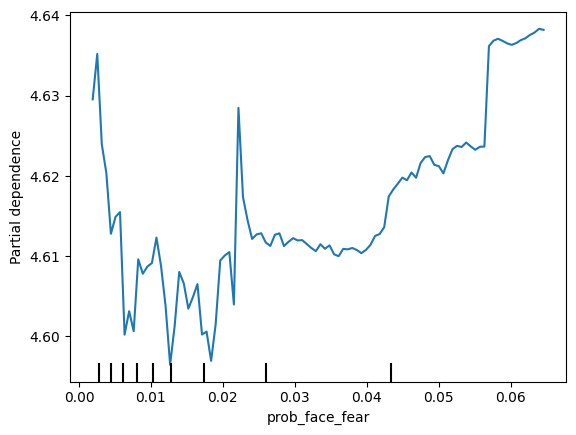

In [195]:
from sklearn.inspection import partial_dependence, PartialDependenceDisplay

PartialDependenceDisplay.from_estimator(rf, X, ['prob_face_fear'])
plt.show()

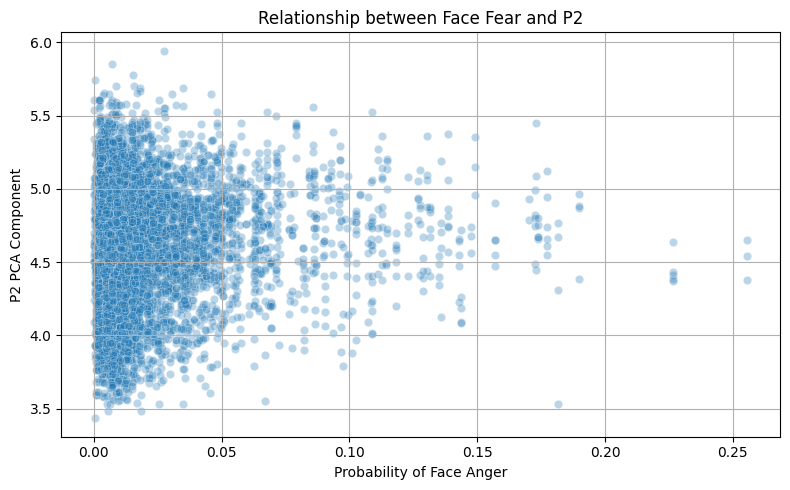

In [196]:
# Re-import necessary libraries after kernel reset
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Simulate example data structure for the plot (replace with actual data in real usage)
# This is just to reinitialize after kernel reset
# Replace this with loading actual 'all_data' if available
import numpy as np
np.random.seed(0)

# Scatterplot of prob_face_anger vs P2_pca
plt.figure(figsize=(8, 5))
sns.scatterplot(x=all_data["prob_face_fear"], y=all_data["p3"], alpha=0.3)
plt.xlabel("Probability of Face Anger")
plt.ylabel("P2 PCA Component")
plt.title("Relationship between Face Fear and P2")
plt.grid(True)
plt.tight_layout()
plt.show()


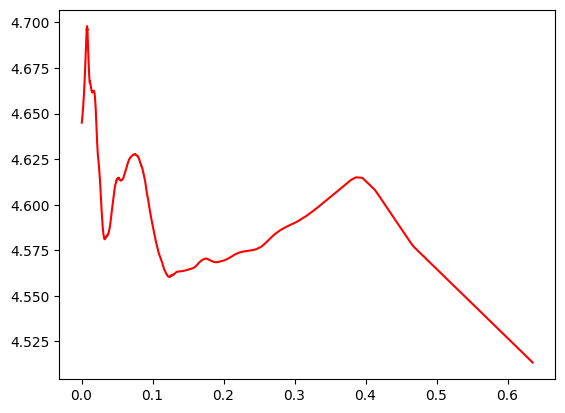

In [197]:
import statsmodels.api as sm
x = all_data["prob_face_surprise"]
y = all_data["p3"]
lowess = sm.nonparametric.lowess
z = lowess(y, x, frac=0.2)
plt.plot(z[:, 0], z[:, 1], color='red')

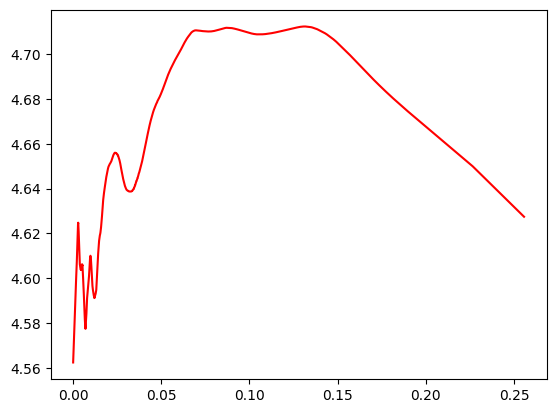

In [198]:
import statsmodels.api as sm
x = all_data["prob_face_fear"]
y = all_data["p3"]
lowess = sm.nonparametric.lowess
z = lowess(y, x, frac=0.2)
plt.plot(z[:, 0], z[:, 1], color='red')

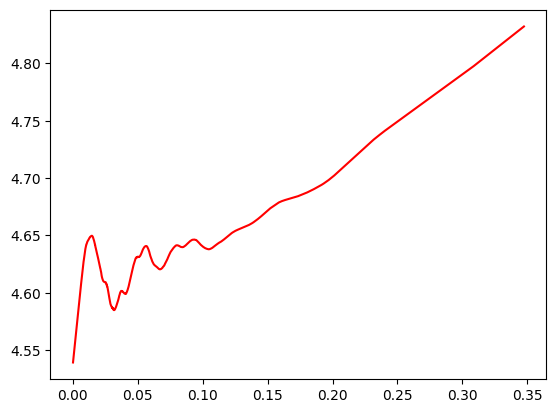

In [199]:
import statsmodels.api as sm
x = all_data["prob_face_anger"]
y = all_data["p3"]
lowess = sm.nonparametric.lowess
z = lowess(y, x, frac=0.2)
plt.plot(z[:, 0], z[:, 1], color='red')

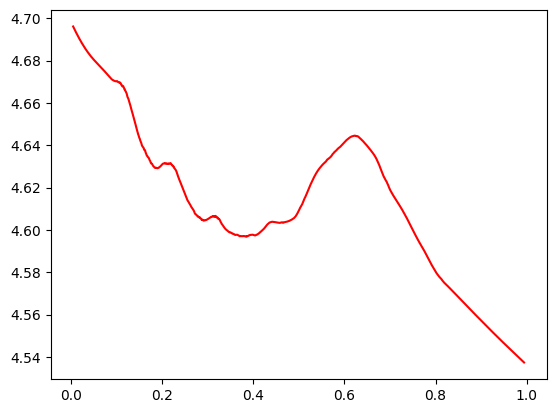

In [200]:
import statsmodels.api as sm
x = all_data["prob_face_happiness"]
y = all_data["p3"]
lowess = sm.nonparametric.lowess
z = lowess(y, x, frac=0.2)
plt.plot(z[:, 0], z[:, 1], color='red')

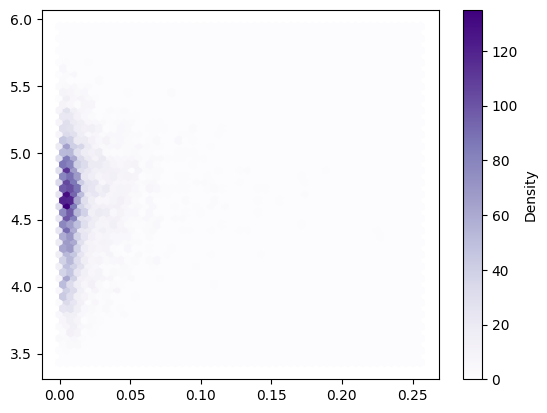

In [201]:
x = all_data["prob_face_fear"]
y = all_data["p3"]
plt.hexbin(x, y, gridsize=50, cmap="Purples")
plt.colorbar(label="Density")


/tmp/ipykernel_4182863/3866520697.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



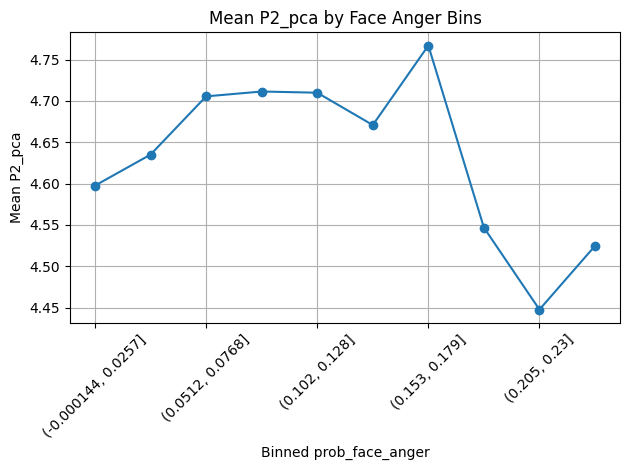

In [202]:
binned = pd.cut(all_data["prob_face_fear"], bins=10)
means = all_data.groupby(binned)["p3"].mean()

# Plot
means.plot(marker='o', linestyle='-')
plt.xlabel("Binned prob_face_anger")
plt.ylabel("Mean P2_pca")
plt.title("Mean P2_pca by Face Anger Bins")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


/tmp/ipykernel_4182863/464177220.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



<Axes: xlabel='prob_face_fear'>

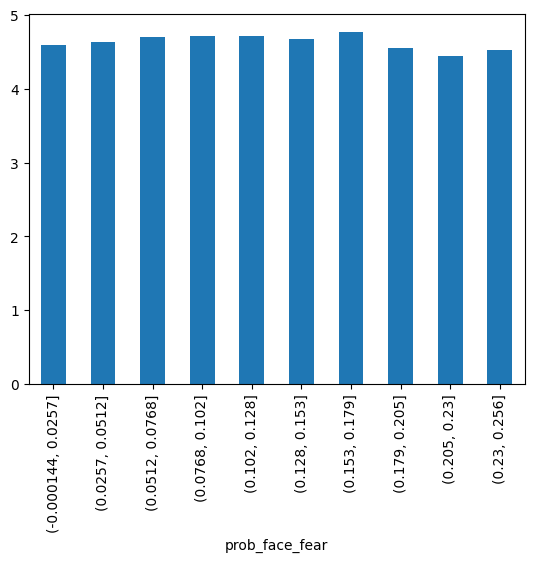

In [203]:
binned = pd.cut(all_data["prob_face_fear"], bins=10)
grouped = all_data.groupby(binned)["p3"].mean()
grouped.plot(kind="bar")


In [204]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# Features and target
X = all_data[["prob_face_fear", "prob_face_anger", "prob_face_surprise", "prob_face_neutral", "prob_face_contempt", "prob_face_disgust", "prob_face_happiness"]]  # or multiple features
y = all_data["p3"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit tree
tree = DecisionTreeRegressor(max_depth=4, random_state=42)
tree.fit(X_train, y_train)

# Predict and evaluate
y_pred = tree.predict(X_test)
print("R^2:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

R^2: 0.030566700884027687
MSE: 0.13466054533457567


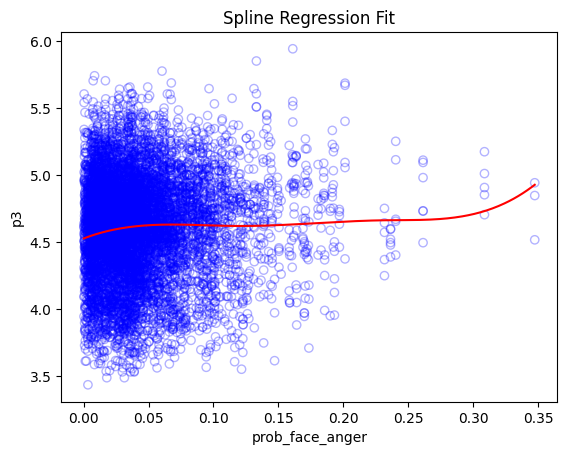

In [205]:
import statsmodels.api as sm
from patsy import dmatrix

# Generate spline basis for prob_face_anger
x_spline = dmatrix("bs(prob_face_anger, df=5, degree=3, include_intercept=False)", 
                   data=all_data, return_type='dataframe')

# Fit model
y = all_data["p3"]
model = sm.OLS(y, x_spline).fit()

# Predict
x_pred = np.linspace(all_data["prob_face_anger"].min(), all_data["prob_face_anger"].max(), 300)
x_pred_spline = dmatrix("bs(x, df=5, degree=3, include_intercept=False)", 
                        {"x": x_pred}, return_type='dataframe')
y_pred = model.predict(x_pred_spline)

# Plot
plt.scatter(all_data["prob_face_anger"], y, facecolors='none', edgecolors='b', alpha=0.3)
plt.plot(x_pred, y_pred, color="red")
plt.xlabel("prob_face_anger")
plt.ylabel("p3")
plt.title("Spline Regression Fit")
plt.show()


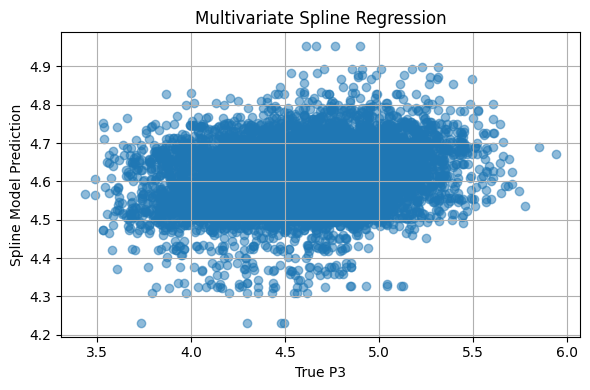

In [206]:
# Re-import necessary modules after kernel reset
import pandas as pd
import numpy as np
from sklearn.preprocessing import SplineTransformer
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# Simulate minimal structure (replace this with actual `all_data`)
np.random.seed(0)
N = 500

# Features for GAM-like spline model
features = ["prob_face_fear", "prob_face_anger", "prob_face_surprise", "prob_face_neutral", "prob_face_contempt", "prob_face_disgust", "prob_face_happiness"]  # or multiple features
X = all_data[features]
y = all_data["p3"]

# Multivariate spline regression via sklearn pipeline
spline_model = make_pipeline(
    SplineTransformer(degree=3, n_knots=5, include_bias=False),
    LinearRegression()
)
spline_model.fit(X, y)
spline_preds = spline_model.predict(X)

# Plot predictions vs true
plt.figure(figsize=(6, 4))
plt.scatter(y, spline_preds, alpha=0.5)
plt.xlabel("True P3")
plt.ylabel("Spline Model Prediction")
plt.title("Multivariate Spline Regression")
plt.grid(True)
plt.tight_layout()
plt.show()


In [207]:
# Features and target
X = all_data[[
    "prob_face_anger", "prob_face_happiness", "prob_face_sadness",
    "prob_face_fear", "prob_face_disgust", "prob_face_surprise", "smile"
]]
y = all_data["p3"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

 99%|===================| 1646/1657 [01:30<00:00]        

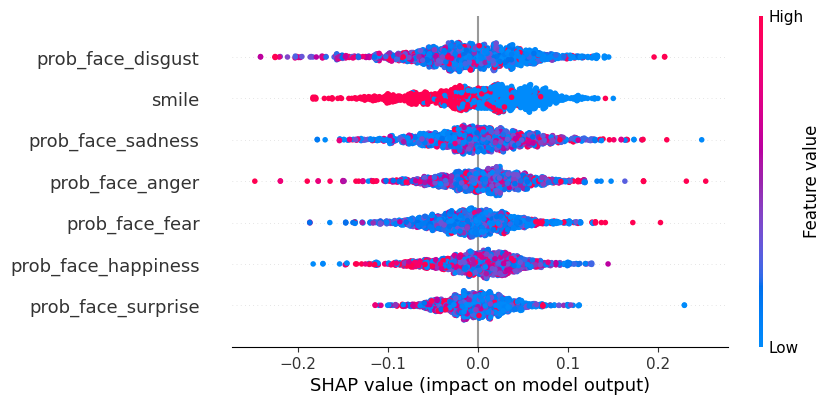

In [208]:
import shap
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor().fit(X_train, y_train)
explainer = shap.Explainer(rf, X_train)
shap_values = explainer(X_test)
shap.plots.beeswarm(shap_values)

In [209]:
# Features and target
X = all_data[[
    "prob_face_anger", "prob_face_happiness", "prob_face_sadness",
    "prob_face_fear", "prob_face_disgust", "prob_face_surprise", "smile"
]]
y = all_data["p3"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [210]:
from pygam import LinearGAM, s

gam = LinearGAM(s(0) + s(1) + s(2) + s(3) + s(4) + s(5) + s(6)).fit(X_train, y_train)
y_pred = gam.predict(X_test)

print("GAM R²:", r2_score(y_test, y_pred))

GAM R²: 0.029347900831570906


 99%|===================| 1638/1657 [01:30<00:01]        

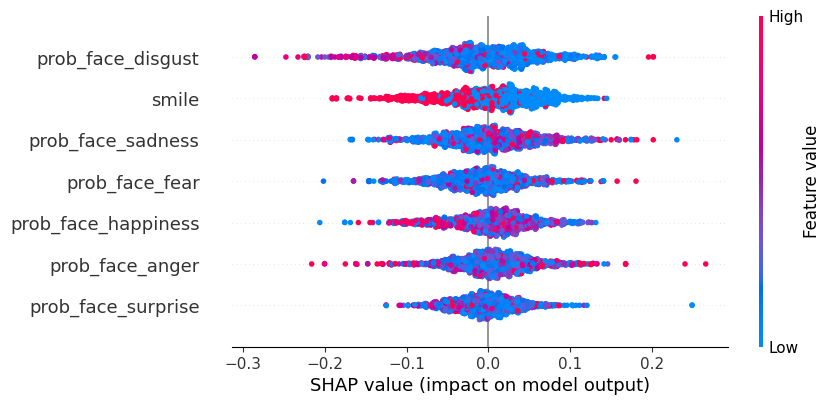

In [211]:
import shap
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor().fit(X_train, y_train)
explainer = shap.Explainer(rf, X_train)
shap_values = explainer(X_test)
shap.plots.beeswarm(shap_values)

# labels per turn

In [212]:
directory = "/u/sebono/conversational_dominance/data/external/CANDOR/transcript_audiophile/"
directory_file = directory + f"{file_name}.csv"
transcript_audiophile = pd.read_csv(directory_file).iloc[1:]
transcript_audiophile.head()

,turn_id,speaker,start,stop,utterance,interval,delta,questions,end_question,overlap,n_words
1,1,5e11882114ae638303c715d9,138.54,138.75,mm.,-0.21,0.21,0,False,True,1
2,2,5d06b3a3ae1dc1000167e533,139.14,139.82,Hold,0.39,0.68,0,False,False,1
3,3,5e11882114ae638303c715d9,139.24,139.86,Who are you?,-0.58,0.62,1,True,True,3
4,4,5d06b3a3ae1dc1000167e533,139.82,140.16,on.,-0.04,0.34,0,False,True,1
5,5,5e11882114ae638303c715d9,140.44,140.76,"Yeah,",0.28,0.32,0,False,False,1


In [213]:
transcript_audiophile["start"] = transcript_audiophile["start"].astype(int)
transcript_audiophile["stop"] = transcript_audiophile["stop"].astype(int)
transcript_audiophile['tokens'] = filtered_tokens_p1[1:]

In [214]:
transcript_audiophile[transcript_audiophile['speaker']==speakers[0]].head()

,turn_id,speaker,start,stop,utterance,interval,delta,questions,end_question,overlap,n_words,tokens
2,2,5d06b3a3ae1dc1000167e533,139,139,Hold,0.39,0.68,0,False,False,1,"[tensor(23588), tensor(220)]"
4,4,5d06b3a3ae1dc1000167e533,139,140,on.,-0.04,0.34,0,False,True,1,"[tensor(389), tensor(13), tensor(220)]"
6,6,5d06b3a3ae1dc1000167e533,141,142,I'm good. How are you?,0.38,1.11,1,True,False,6,"[tensor(358), tensor(2846), tensor(1695), tens..."
8,8,5d06b3a3ae1dc1000167e533,144,147,Good. I got a couple of dogs running crazy rig...,1.08,3.36,0,False,False,11,"[tensor(7839), tensor(13), tensor(358), tensor..."
10,10,5d06b3a3ae1dc1000167e533,147,151,me. But uh have you done one of these before?,-0.15,4.05,1,True,True,10,"[tensor(757), tensor(13), tensor(2030), tensor..."


In [215]:
path_annotations = "/u/sebono/conversational_dominance/data/processed/CANDOR/affective_labels/"
annotation_file = path_annotations + f"{file_name}.csv"
affective_labels = pd.read_csv(annotation_file)

In [216]:
affective_labels["timedelta"] = pd.to_timedelta(affective_labels["timedelta"])
affective_labels["time_bin"] = affective_labels["timedelta"].dt.total_seconds().astype(int)
affective_labels.head()

,timedelta,user_id,f0,intensity,jitter,log_energy,mfcc_0,mfcc_1,mfcc_10,mfcc_11,...,prob_face_contempt,prob_face_disgust,prob_face_fear,prob_face_happiness,prob_face_neutral,prob_face_sadness,prob_face_surprise,smile,is_speaking,time_bin
0,0 days 00:00:00,5d06b3a3ae1dc1000167e533,NaN,0.0,NaN,-99.172266,-511.36688,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,0
1,0 days 00:00:00,5e11882114ae638303c715d9,NaN,0.0,NaN,-115.977709,-498.45502,NaN,NaN,NaN,...,0.014664,0.008122,0.006395,0.732815,0.131040,0.028822,0.065493,1.0,False,0
2,0 days 00:00:01,5d06b3a3ae1dc1000167e533,NaN,0.0,NaN,-99.172266,-511.36688,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,1
3,0 days 00:00:01,5e11882114ae638303c715d9,NaN,0.0,NaN,-115.977709,-498.45502,NaN,NaN,NaN,...,0.001402,0.000726,0.060252,0.002870,0.564665,0.321175,0.030484,0.0,False,1
4,0 days 00:00:02,5d06b3a3ae1dc1000167e533,NaN,0.0,NaN,-99.172266,-511.36688,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,2


In [217]:
cols = ['intensity', 'jitter', 'log_energy',
       'mfcc_0', 'mfcc_1', 'mfcc_10', 'mfcc_11', 'mfcc_12', 'mfcc_13',
       'mfcc_14', 'mfcc_15', 'mfcc_16', 'mfcc_17', 'mfcc_18', 'mfcc_19',
       'mfcc_2', 'mfcc_3', 'mfcc_4', 'mfcc_5', 'mfcc_6', 'mfcc_7', 'mfcc_8',
       'mfcc_9', 'onset_strength', 'poly_features_0', 'poly_features_1',
       'shimmer', 'spectral_bandwidth', 'spectral_centroid',
       'spectral_contrast_0', 'spectral_contrast_1', 'spectral_contrast_2',
       'spectral_contrast_3', 'spectral_contrast_4', 'spectral_contrast_5',
       'spectral_contrast_6', 'spectral_flatness', 'spectral_rolloff',
       'zero_crossing_rate', 'gaze_on', 'nod_no', 'nod_yes', 'prob_face_anger',
       'prob_face_contempt', 'prob_face_disgust', 'prob_face_fear',
       'prob_face_happiness', 'prob_face_neutral', 'prob_face_sadness',
       'prob_face_surprise', 'smile'
]


In [218]:
affective_labels_spk0 = affective_labels[affective_labels['user_id']==speakers[0]].reset_index(drop=True)
affective_labels_spk1 = affective_labels[affective_labels['user_id']==speakers[1]].reset_index(drop=True)
assert affective_labels_spk1.shape == affective_labels_spk0.shape

In [219]:
assert np.cumsum([len(tok) for tok in transcript_audiophile['tokens']])[-1] == len(filtered_encodings_p1) -len(filtered_tokens_p1[0])

In [220]:
from itertools import count

# Start from offset
start_index = len(filtered_tokens_p1[0])
counter = count(start=start_index)

# Function to assign token indices
def assign_indices(token_list):
    return [next(counter) for _ in token_list]

# Apply to DataFrame
transcript_audiophile["ppl"] = transcript_audiophile["tokens"].apply(assign_indices)

In [221]:
transcript_audiophile["p1"] = transcript_audiophile["ppl"].apply(
    lambda idxs: np.asarray(filtered_ppl_p1)[idxs].mean(axis=0) if len(idxs) > 0 else np.nan
)
transcript_audiophile["p2"] = transcript_audiophile["ppl"].apply(
    lambda idxs: np.asarray(filtered_ppl_p2)[idxs].mean(axis=0) if len(idxs) > 0 else np.nan
)
transcript_audiophile["p3"] = transcript_audiophile["ppl"].apply(
    lambda idxs: np.asarray(filtered_ppl_p3)[idxs].mean(axis=0) if len(idxs) > 0 else np.nan
)

In [222]:
transcript_audiophile_spk0 = transcript_audiophile[transcript_audiophile['speaker']==speakers[0]].reset_index(drop=True)
transcript_audiophile_spk1 = transcript_audiophile[transcript_audiophile['speaker']==speakers[1]].reset_index(drop=True)

In [223]:
# This will compute the mean of each affective column between start and stop (inclusive)
transcript_audiophile_spk0[cols] = transcript_audiophile_spk0.apply(
    lambda x: affective_labels_spk0.loc[
        (affective_labels_spk0["time_bin"] >= x["start"]) & 
        (affective_labels_spk0["time_bin"] <= x["stop"]),
        cols
    ].mean(),
    axis=1
)
# This will compute the mean of each affective column between start and stop (inclusive)
transcript_audiophile_spk1[cols] = transcript_audiophile_spk1.apply(
    lambda x: affective_labels_spk1.loc[
        (affective_labels_spk1["time_bin"] >= x["start"]) & 
        (affective_labels_spk1["time_bin"] <= x["stop"]),
        cols
    ].mean(),
    axis=1
)

In [224]:
transcript_audiophile_spk1

,turn_id,speaker,start,stop,utterance,interval,delta,questions,end_question,overlap,...,nod_yes,prob_face_anger,prob_face_contempt,prob_face_disgust,prob_face_fear,prob_face_happiness,prob_face_neutral,prob_face_sadness,prob_face_surprise,smile
0,1,5e11882114ae638303c715d9,138,138,mm.,-0.21,0.21,0,False,True,...,0.0,0.188041,0.036960,0.082002,0.011847,0.275964,0.324073,0.057451,0.023662,0.000000
1,3,5e11882114ae638303c715d9,139,139,Who are you?,-0.58,0.62,1,True,True,...,0.0,0.039737,0.017130,0.006823,0.011034,0.050066,0.730739,0.048657,0.095814,0.000000
2,5,5e11882114ae638303c715d9,140,140,"Yeah,",0.28,0.32,0,False,False,...,0.0,0.035230,0.019702,0.005312,0.017440,0.047718,0.673644,0.068831,0.132123,0.000000
3,7,5e11882114ae638303c715d9,142,143,aren't too bad.,-0.11,1.02,0,False,True,...,0.0,0.023567,0.023177,0.017270,0.007304,0.050874,0.675368,0.079489,0.122952,1.000000
4,9,5e11882114ae638303c715d9,147,147,"Okay,",-0.06,0.21,0,False,True,...,0.0,0.000438,0.006056,0.001005,0.000513,0.968884,0.004923,0.000616,0.017565,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
452,905,5e11882114ae638303c715d9,1793,1794,evening,0.00,0.22,0,False,False,...,0.0,0.051085,0.025975,0.102405,0.012592,0.414180,0.287956,0.047742,0.058066,0.500000
453,907,5e11882114ae638303c715d9,1794,1794,camera.,-0.13,0.33,0,False,True,...,0.0,0.073704,0.019891,0.079939,0.011209,0.340809,0.389145,0.067039,0.018263,0.000000
454,909,5e11882114ae638303c715d9,1795,1796,"What,",-0.67,0.21,0,False,True,...,0.5,0.086150,0.036933,0.047940,0.004926,0.170567,0.576012,0.067611,0.009861,0.000000
455,911,5e11882114ae638303c715d9,1797,1797,"yep,",-0.12,0.81,0,False,True,...,1.0,0.048449,0.022957,0.020704,0.007198,0.136946,0.687678,0.065406,0.010662,0.000000


In [225]:
all_data = pd.concat([transcript_audiophile_spk0.dropna(), transcript_audiophile_spk1.dropna()], ignore_index=True)

In [226]:
# BEFORE
col_1 = ["p1","p2","p3"]

corr, fig_corr, p, fig_p, fig_r = correlation_heatmap(col_1,cols,all_data)

In [227]:
fig_corr

In [228]:
fig_r

In [229]:
fig_p

In [230]:
from scipy.stats import spearmanr
import pandas as pd

# Perform correlation
stat, pval = spearmanr(all_data['p3'], all_data[cols], nan_policy='omit')

# Extract just the relevant row (first row after the scalar)
correlation_vector = stat[0, 1:]
pval_vector = pval[0, 1:]

# Wrap into a DataFrame
corr_df = pd.DataFrame({
    "feature": cols,
    "spearman_r": correlation_vector,
    "p_value": pval_vector
})

# Sort by absolute correlation
corr_df["abs_r"] = corr_df["spearman_r"].abs()
corr_df = corr_df.sort_values("abs_r", ascending=False)

corr_df[["feature", "spearman_r", "p_value"]]


,feature,spearman_r,p_value
3,mfcc_0,0.430247,2.532612e-38
6,mfcc_11,-0.426322,1.379812e-37
35,spectral_contrast_6,0.417723,5.237262e-36
24,poly_features_0,-0.413642,2.836361e-35
25,poly_features_1,0.413032,3.643778e-35
2,log_energy,0.410102,1.204858e-34
4,mfcc_1,0.392142,1.426342e-31
27,spectral_bandwidth,-0.384562,2.487036e-30
29,spectral_contrast_0,0.356494,5.211945e-26
34,spectral_contrast_5,0.340861,8.778743e-24


In [238]:
from scipy.stats import spearmanr
import pandas as pd

# Perform correlation
stat, pval = spearmanr(all_data['p2'], all_data[cols], nan_policy='omit')

# Extract just the relevant row (first row after the scalar)
correlation_vector = stat[0, 1:]
pval_vector = pval[0, 1:]

# Wrap into a DataFrame
corr_df = pd.DataFrame({
    "feature": cols,
    "spearman_r": correlation_vector,
    "p_value": pval_vector
})

# Sort by absolute correlation
corr_df["abs_r"] = corr_df["spearman_r"].abs()
corr_df = corr_df.sort_values("abs_r", ascending=False)

corr_df[["feature", "spearman_r", "p_value"]]


,feature,spearman_r,p_value
39,gaze_on,-0.177695,2.981631e-07
8,mfcc_13,0.148957,1.823305e-05
15,mfcc_2,0.139247,6.246633e-05
50,smile,0.132442,1.413060e-04
7,mfcc_12,0.130281,1.816611e-04
17,mfcc_4,-0.113814,1.087796e-03
10,mfcc_15,-0.112900,1.193692e-03
20,mfcc_7,0.109317,1.707342e-03
4,mfcc_1,-0.105789,2.404789e-03
36,spectral_flatness,-0.105672,2.431841e-03


In [239]:
from scipy.stats import spearmanr
import pandas as pd

# Perform correlation
stat, pval = spearmanr(all_data['p1'], all_data[cols], nan_policy='omit')

# Extract just the relevant row (first row after the scalar)
correlation_vector = stat[0, 1:]
pval_vector = pval[0, 1:]

# Wrap into a DataFrame
corr_df = pd.DataFrame({
    "feature": cols,
    "spearman_r": correlation_vector,
    "p_value": pval_vector
})

# Sort by absolute correlation
corr_df["abs_r"] = corr_df["spearman_r"].abs()
corr_df = corr_df.sort_values("abs_r", ascending=False)

corr_df[["feature", "spearman_r", "p_value"]]


,feature,spearman_r,p_value
2,log_energy,0.313145,3.890532e-20
35,spectral_contrast_6,0.305957,2.986105e-19
3,mfcc_0,0.303543,5.847178e-19
30,spectral_contrast_1,0.294211,7.405658e-18
25,poly_features_1,0.293870,8.110394e-18
24,poly_features_0,-0.293685,8.522013e-18
34,spectral_contrast_5,0.292872,1.057964e-17
31,spectral_contrast_2,0.286777,5.239633e-17
27,spectral_bandwidth,-0.284737,8.872173e-17
5,mfcc_10,-0.274773,1.093410e-15


In [241]:
from sklearn.feature_selection import mutual_info_regression

# X: affective features, y: P2_pca
X = all_data[cols].fillna(0)  # Replace NaNs or handle appropriately
y = all_data['p1']

mi_scores = mutual_info_regression(X, y, random_state=42)

mi_df = pd.DataFrame({
    "feature": cols,
    "mutual_info": mi_scores
}).sort_values("mutual_info", ascending=False)

print(mi_df)


                feature  mutual_info
27   spectral_bandwidth     0.122348
3                mfcc_0     0.117715
25      poly_features_1     0.107805
35  spectral_contrast_6     0.102418
24      poly_features_0     0.098663
2            log_energy     0.094886
31  spectral_contrast_2     0.091824
4                mfcc_1     0.088325
28    spectral_centroid     0.086631
34  spectral_contrast_5     0.083754
44    prob_face_disgust     0.083347
16               mfcc_3     0.078045
5               mfcc_10     0.075572
33  spectral_contrast_4     0.070899
12              mfcc_17     0.060221
6               mfcc_11     0.056937
41              nod_yes     0.049734
23       onset_strength     0.049368
13              mfcc_18     0.046145
26              shimmer     0.045630
38   zero_crossing_rate     0.042509
30  spectral_contrast_1     0.042340
29  spectral_contrast_0     0.037713
37     spectral_rolloff     0.035582
11              mfcc_16     0.034414
32  spectral_contrast_3     0.033335
9

In [242]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

rf_importances = pd.DataFrame({
    "feature": cols,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

print(rf_importances)

                feature  importance
3                mfcc_0    0.071752
35  spectral_contrast_6    0.053977
18               mfcc_5    0.045051
30  spectral_contrast_1    0.035003
26              shimmer    0.029492
46  prob_face_happiness    0.028619
1                jitter    0.027523
23       onset_strength    0.026197
13              mfcc_18    0.024956
9               mfcc_14    0.024243
44    prob_face_disgust    0.024130
38   zero_crossing_rate    0.023247
15               mfcc_2    0.022939
42      prob_face_anger    0.020950
17               mfcc_4    0.020334
20               mfcc_7    0.020031
43   prob_face_contempt    0.019780
8               mfcc_13    0.019659
16               mfcc_3    0.019635
48    prob_face_sadness    0.019223
49   prob_face_surprise    0.019151
47    prob_face_neutral    0.018897
22               mfcc_9    0.018107
29  spectral_contrast_0    0.018105
0             intensity    0.018078
2            log_energy    0.017989
10              mfcc_15    0

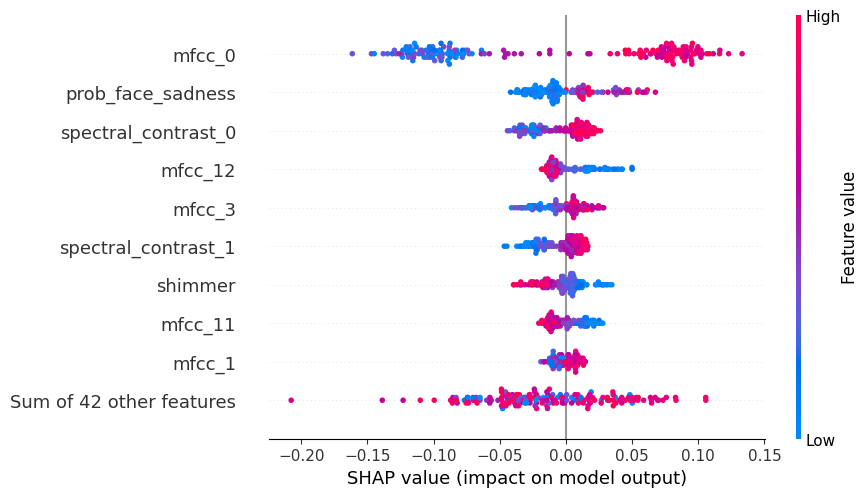

In [244]:
# Features and target
X = all_data[cols]
y = all_data["p3"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

import shap
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor().fit(X_train, y_train)
explainer = shap.Explainer(rf, X_train)
shap_values = explainer(X_test)
shap.plots.beeswarm(shap_values)

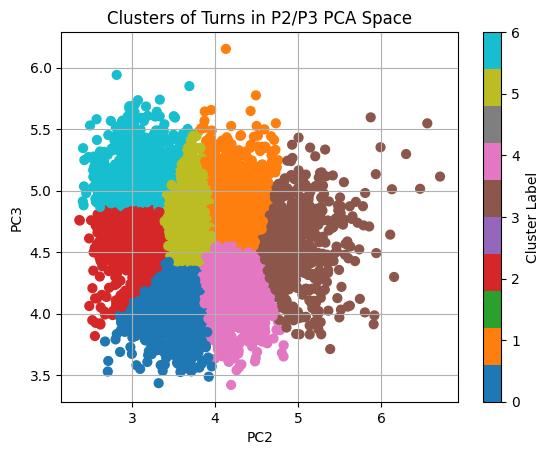

In [245]:
#KMeans (assumes spherical clusters):
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=7, random_state=0)
labels = kmeans.fit_predict(all_data_filtered[["p2","p3"]])
import matplotlib.pyplot as plt
plt.scatter(all_data_filtered["p2"], all_data_filtered["p3"], c=labels, cmap="tab10", s=40)
plt.title("Clusters of Turns in P2/P3 PCA Space")
plt.xlabel("PC2")
plt.ylabel("PC3")
plt.colorbar(label="Cluster Label")
plt.grid(True)
plt.show()


In [249]:
# BEFORE
col_1 = ['prob_face_anger',
 'prob_face_contempt',
 'prob_face_disgust',
 'prob_face_fear',
 'prob_face_happiness',
 'prob_face_neutral',
 'prob_face_sadness',
 'prob_face_surprise',
 'smile','intensity',
 'jitter',
 'log_energy',
 'mfcc_0',
 'mfcc_1',
 'mfcc_10',
 'mfcc_11',
 'mfcc_12',
 'mfcc_13',
 'mfcc_14',
 'mfcc_15',
 'mfcc_16',
 'mfcc_17',
 'mfcc_18',
 'mfcc_19',
 'mfcc_2',
 'mfcc_3',
 'mfcc_4',
 'mfcc_5',
 'mfcc_6',
 'mfcc_7',
 'mfcc_8',
 'mfcc_9',
 'onset_strength',
 'poly_features_0',
 'poly_features_1',
 'shimmer',
 'spectral_bandwidth',
 'spectral_centroid',
 'spectral_contrast_0',
 'spectral_contrast_1',
 'spectral_contrast_2',
 'spectral_contrast_3',
 'spectral_contrast_4',
 'spectral_contrast_5',
 'spectral_contrast_6',
 'spectral_flatness',
 'spectral_rolloff',
 'zero_crossing_rate']
col_2=['p1', 'p2', 'p3']
corr, fig_corr, p, fig_p, fig_r = correlation_heatmap(col_1,col_2,all_data)

In [250]:
fig_corr

In [264]:
all_data['p1'].shape, all_data[col_1].shape

((821,), (821, 48))

In [269]:
from scipy.stats import spearmanr
import pandas as pd

# Perform correlation
stat, pval = spearmanr(all_data['p3'], all_data[col_1], nan_policy='omit')

# Extract just the relevant row (first row after the scalar)
correlation_vector = stat[0, 1:]
pval_vector = pval[0, 1:]

# Wrap into a DataFrame
corr_df = pd.DataFrame({
    "feature": col_1,
    "spearman_r": correlation_vector,
    "p_value": pval_vector
})

# Sort by absolute correlation
corr_df["abs_r"] = corr_df["spearman_r"].abs()
corr_df = corr_df.sort_values("abs_r", ascending=False)

corr_df[["feature", "spearman_r", "p_value"]]


,feature,spearman_r,p_value
12,mfcc_0,0.430247,2.532612e-38
15,mfcc_11,-0.426322,1.379812e-37
44,spectral_contrast_6,0.417723,5.237262e-36
33,poly_features_0,-0.413642,2.836361e-35
34,poly_features_1,0.413032,3.643778e-35
11,log_energy,0.410102,1.204858e-34
13,mfcc_1,0.392142,1.426342e-31
36,spectral_bandwidth,-0.384562,2.487036e-30
38,spectral_contrast_0,0.356494,5.211945e-26
43,spectral_contrast_5,0.340861,8.778743e-24
